#  MobileNetV2 — Cracking Defect Detection

This notebook trains a **MobileNetV2** transfer-learning model to classify surface images as **Cracking** or **No Cracking**.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

---
##  Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-05-21 14:51:07.999610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779371468.102110   16189 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779371468.129740   16189 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-21 14:51:08.372947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Cracking/` and `No_Cracking/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [2]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

cracking_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Cracking", "*.jpg")))
no_cracking_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Cracking", "*.jpg")))

print(f"Cracking images    : {len(cracking_files)}")
print(f"No_Cracking images : {len(no_cracking_files)}")

# Label: Cracking = 1, No_Cracking = 0
all_files  = cracking_files + no_cracking_files
all_labels = [1] * len(cracking_files) + [0] * len(no_cracking_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Cracking images    : 1663
No_Cracking images : 2042

Train : 2964
Val   : 370
Test  : 371


### 1.1 — Build `tf.data` pipelines with augmentation

In [3]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1779371475.449389   16189 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

In [11]:
class_names = ["No_Cracking", "Cracking"]

2026-04-20 23:48:36.382977: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


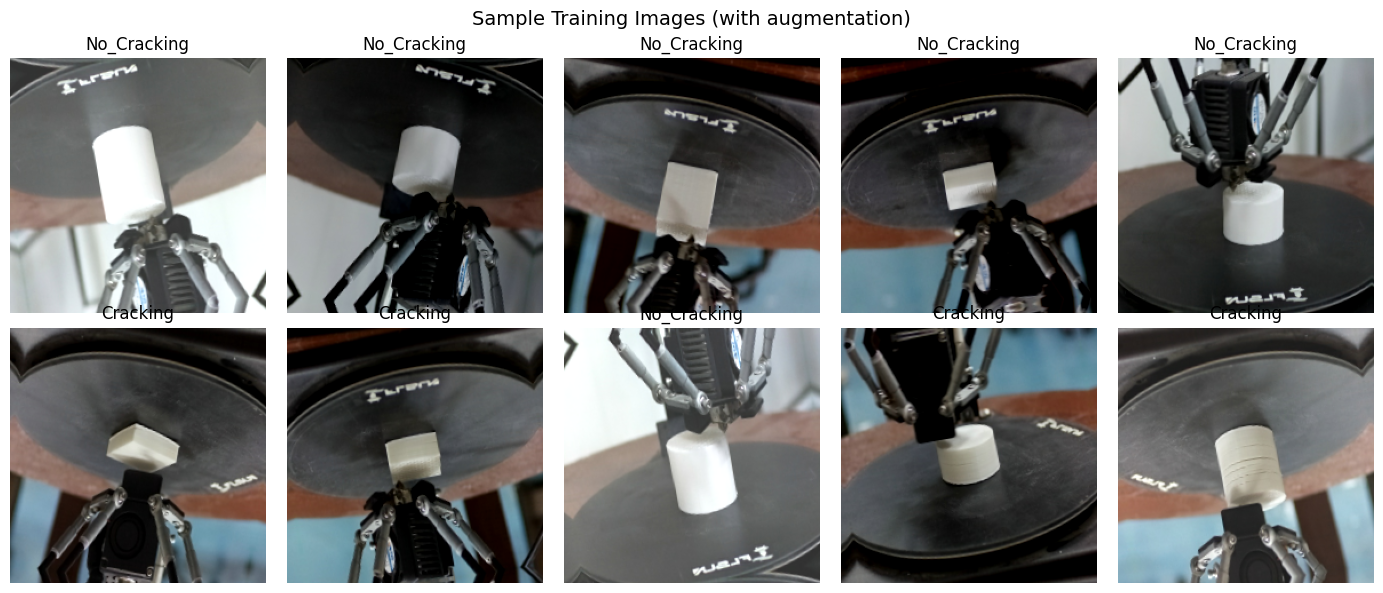

In [5]:
class_names = ["No_Cracking", "Cracking"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

* Load **MobileNetV2** pretrained on ImageNet (`include_top=False`)
* **Freeze** all base layers
* Add: `GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(1, sigmoid)`

In [6]:
# ---------- Load pretrained base ----------
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

# ---------- Build classification head ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_Cracking")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Base model layers : 154
Trainable weights : 0


Model: "MobileNetV2_Cracking"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [8]:
EPOCHS = 50
BEST_MODEL_PATH = "best_mobilenetv2_cracking.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1776725356.652558   16066 service.cc:148] XLA service 0x79ff9c003060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776725356.653145   16066 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-04-20 23:49:16.846254: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776725357.525418   16066 cuda_dnn.cc:529] Loaded cuDNN version 90300


 6/93 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5562 - loss: 0.6923

I0000 00:00:1776725351.156686   16066 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/93 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.7667 - loss: 0.4761
Epoch 1: val_loss improved from None to 0.21699, saving model to best_mobilenetv2_cracking.h5


...


Epoch 12: finished saving model to best_mobilenetv2_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9764 - loss: 0.0676 - val_accuracy: 0.9568 - val_loss: 0.0998 - learning_rate: 5.0000e-05
Epoch 13/50
 6/93 ━━━━━━━━━━━━━━━━━━━━ 3:13 2s/step - accuracy: 0.9694 - loss: 0.0887
Epoch 13: val_loss did not improve from 0.09981
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9852 - loss: 0.0558 - val_accuracy: 0.9378 - val_loss: 0.1438 - learning_rate: 5.0000e-05
Epoch 14/50
19/93 ━━━━━━━━━━━━━━━━━━━━ 48s 651ms/step - accuracy: 0.9793 - loss: 0.0559
Epoch 14: val_loss did not improve from 0.09981
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9818 - loss: 0.0586 - val_accuracy: 0.9459 - val_loss: 0.1189 - learning_rate: 5.0000e-05
Epoch 15/50
32/93 ━━━━━━━━━━━━━━━━━━━━ 24s 395ms/step - accuracy: 0.9789 - loss: 0.0624
Epoch 15: val_loss did not improve from 0.09981
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9808 - loss: 0.0569 - val_accuracy: 0.9486 


Epoch 16: finished saving model to best_mobilenetv2_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9804 - loss: 0.0589 - val_accuracy: 0.9622 - val_loss: 0.0855 - learning_rate: 5.0000e-05
Epoch 17/50
45/93 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step - accuracy: 0.9834 - loss: 0.0516
Epoch 17: val_loss improved from 0.08555 to 0.08144, saving model to best_mobilenetv2_cracking.h5



Epoch 17: finished saving model to best_mobilenetv2_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9841 - loss: 0.0522 - val_accuracy: 0.9622 - val_loss: 0.0814 - learning_rate: 5.0000e-05
Epoch 18/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9785 - loss: 0.0562
Epoch 18: val_loss did not improve from 0.08144
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - accuracy: 0.9808 - loss: 0.0550 - val_accuracy: 0.9649 - val_loss: 0.0944 - learning_rate: 5.0000e-05
Epoch 19/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9850 - loss: 0.0503
Epoch 19: val_loss improved from 0.08144 to 0.07312, saving model to best_mobilenetv2_cracking.h5



Epoch 19: finished saving model to best_mobilenetv2_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9848 - loss: 0.0493 - val_accuracy: 0.9676 - val_loss: 0.0731 - learning_rate: 5.0000e-05
Epoch 20/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9875 - loss: 0.0435
Epoch 20: val_loss did not improve from 0.07312
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9862 - loss: 0.0457 - val_accuracy: 0.9649 - val_loss: 0.0885 - learning_rate: 5.0000e-05
Epoch 21/50
61/93 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9820 - loss: 0.0533
Epoch 21: val_loss did not improve from 0.07312
93/93 ━━━━━━━━━━━━━━━━━━━━ -6s -70450us/step - accuracy: 0.9835 - loss: 0.0480 - val_accuracy: 0.9676 - val_loss: 0.0854 - learning_rate: 5.0000e-05
Epoch 22/50
68/93 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.9834 - loss: 0.0510
Epoch 22: val_loss did not improve from 0.07312
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9875 - loss: 0.0493 - val_accuracy: 0.959


Epoch 23: finished saving model to best_mobilenetv2_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9835 - loss: 0.0468 - val_accuracy: 0.9730 - val_loss: 0.0659 - learning_rate: 5.0000e-05
Epoch 24/50
75/93 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.9800 - loss: 0.0524
Epoch 24: val_loss did not improve from 0.06593
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9801 - loss: 0.0511 - val_accuracy: 0.9676 - val_loss: 0.0774 - learning_rate: 5.0000e-05
Epoch 25/50
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9854 - loss: 0.0487
Epoch 25: val_loss did not improve from 0.06593
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.9852 - loss: 0.0451 - val_accuracy: 0.9676 - val_loss: 0.0714 - learning_rate: 5.0000e-05
Epoch 26/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9858 - loss: 0.0454
Epoch 26: val_loss did not improve from 0.06593
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9848 - loss: 0.0458 - val_accuracy: 0.9649 

---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [8]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

NameError: name 'BEST_MODEL_PATH' is not defined

### 5.2 — Classification metrics

In [10]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.9730
  Precision : 0.9938
  Recall    : 0.9467
  F1-Score  : 0.9697

              precision    recall  f1-score   support

 No_Cracking       0.96      1.00      0.98       202
    Cracking       0.99      0.95      0.97       169

    accuracy                           0.97       371
   macro avg       0.98      0.97      0.97       371
weighted avg       0.97      0.97      0.97       371



### 5.3 — Confusion Matrix

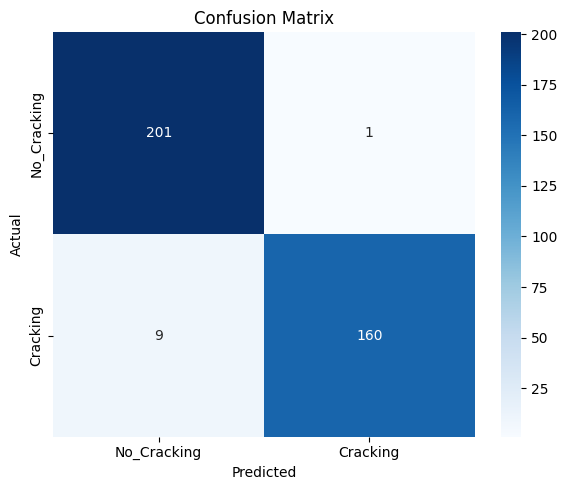

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

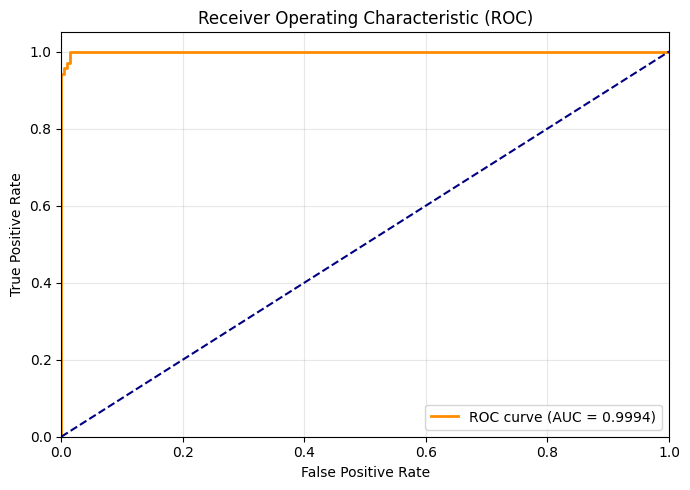

In [12]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

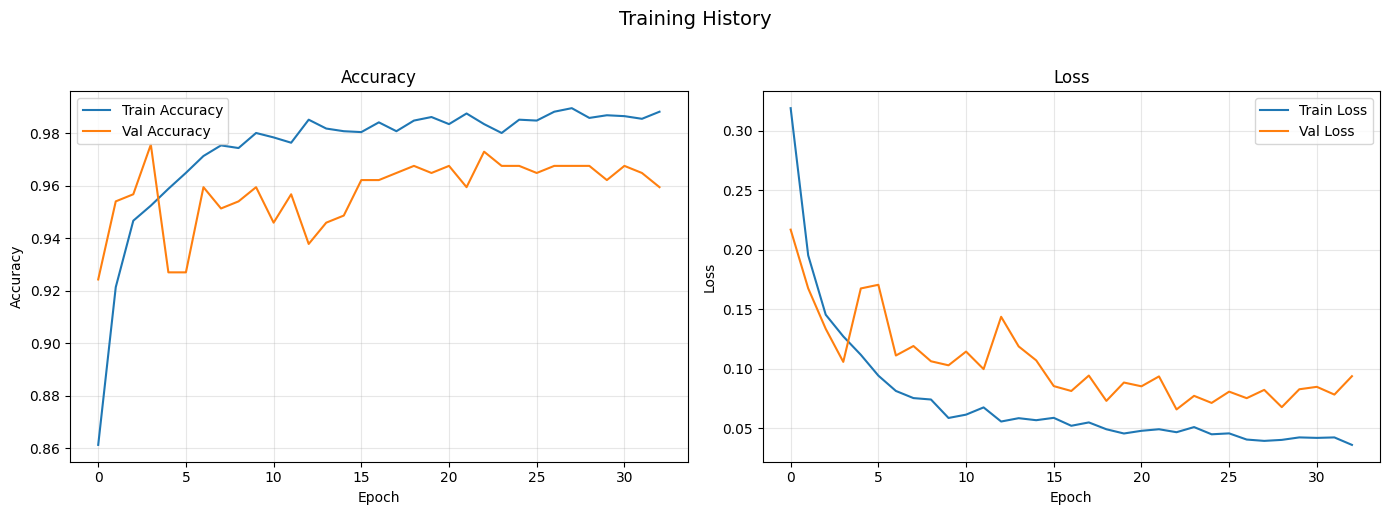

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [14]:
# 1) Save as .h5
H5_PATH = "mobilenetv2_cracking_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = "mobilenetv2_cracking_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       → mobilenetv2_cracking_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mobilenetv2_cracking_savedmodel.

---
### ✅ Done!

The trained MobileNetV2 model for **Cracking vs No_Cracking** detection is now saved and ready for deployment or TFLite conversion.

---
## Round 1 — Fine-Tuning: Unfreeze Last 20 Layers

The base model was fully frozen during the first training phase (only the custom head was trained).  
Here we apply **fine-tuning** by selectively unfreezing the **last 20 layers** of MobileNetV2 and training with a very low learning rate.

| Hyperparameter | Phase 1 (original) | Phase 2 (fine-tuning) |
|----------------|--------------------|-----------------------|
| Base model layers | **All frozen** (0 trainable) | **Last 20 unfrozen** |
| Learning rate | 0.0001 (1e-4) | **0.00001 (1e-5)** |
| Loss | binary_crossentropy | binary_crossentropy |
| Batch size | 32 | 32 |
| Max epochs | 50 | 50 |
| Callbacks | EarlyStopping / ReduceLR / Checkpoint | same |
| Data | same train/val/test splits | same |

> **Why 1e-5?** Fine-tuning requires a much smaller LR than initial training (10× lower here)  
> to avoid destroying the pre-learned ImageNet features in the unfrozen layers.

### Step 1 — Load the best model from Phase 1


In [5]:
# Load the best checkpoint saved during Phase 1
ft_model = keras.models.load_model("best_mobilenetv2_cracking.h5")
print("✅ Phase-1 best model loaded.")

✅ Phase-1 best model loaded.


### Step 2 — Unfreeze the last 20 layers of the MobileNetV2 base

We target only the top of the base model (high-level, task-specific features).  
The early layers (low-level edge/texture detectors) stay frozen to preserve ImageNet weights.

In [6]:
# Locate the MobileNetV2 base inside the loaded model
base_model = ft_model.get_layer("mobilenetv2_1.00_224")

# Keep all base layers frozen first, then selectively unfreeze the last 20
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Summary of trainable status
total   = len(base_model.layers)
frozen  = sum(not l.trainable for l in base_model.layers)
unfrozen = sum(l.trainable for l in base_model.layers)
print(f"Base model total layers : {total}")
print(f"  Frozen                : {frozen}")
print(f"  Unfrozen (last 20)    : {unfrozen}")
print()
ft_model.summary()

Base model total layers : 154
  Frozen                : 134
  Unfrozen (last 20)    : 20



Model: "MobileNetV2_Cracking"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,179 (9.87 MB)

 Trainable params: 1,534,273 (5.85 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2 (12.00 B)

### Step 3 — Recompile with a 10× lower learning rate

A very low LR (`1e-5`) lets the unfrozen weights adapt gently to the cracking task  
without catastrophically forgetting the ImageNet features.

In [7]:
FT_LR = 1e-5   # 10× lower than original 1e-4

ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FT_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print(f"✅ Model recompiled — learning rate = {FT_LR}")

✅ Model recompiled — learning rate = 1e-05


### Step 4 — Callbacks (same as Phase 1) & Train

The best fine-tuned model is saved to a **new file** so Phase 1 weights are not overwritten.

In [4]:
FT_BEST_MODEL_PATH = "best_mobilenetv2_cracking_finetuned.h5"

In [8]:
FT_EPOCHS = 50
FT_BEST_MODEL_PATH = "best_mobilenetv2_cracking_finetuned.h5"

ft_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=FT_BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

# Fine-tune on the same train_ds / val_ds used in Phase 1
ft_history = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    callbacks=ft_callbacks,
)

print("\n✅ Fine-tuning complete.")

Epoch 1/50


I0000 00:00:1778455051.360136  204152 service.cc:148] XLA service 0x7d45e40039d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778455051.360655  204152 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-11 00:17:32.118533: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778455053.701059  204152 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/93 ━━━━━━━━━━━━━━━━━━━━ 27:00 18s/step - accuracy: 0.7500 - loss: 0.7889

I0000 00:00:1778455061.876437  204152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8284 - loss: 0.4747
Epoch 1: val_loss improved from None to 0.12977, saving model to best_mobilenetv2_cracking_finetuned.h5


...


Epoch 25: finished saving model to best_mobilenetv2_cracking_finetuned.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9811 - val_loss: 0.0444 - learning_rate: 1.0000e-05
Epoch 26/50
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9899 - loss: 0.0245
Epoch 26: val_loss did not improve from 0.04437
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9912 - loss: 0.0216 - val_accuracy: 0.9784 - val_loss: 0.0483 - learning_rate: 1.0000e-05
Epoch 27/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9924 - loss: 0.0246
Epoch 27: val_loss did not improve from 0.04437
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9784 - val_loss: 0.0447 - learning_rate: 1.0000e-05
Epoch 28/50
39/93 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.9905 - loss: 0.0225
Epoch 28: val_loss improved from 0.04437 to 0.04350, saving model to best_mobilenetv2_cracking_finetuned.h5



Epoch 28: finished saving model to best_mobilenetv2_cracking_finetuned.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9916 - loss: 0.0198 - val_accuracy: 0.9811 - val_loss: 0.0435 - learning_rate: 1.0000e-05
Epoch 29/50
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9947 - loss: 0.0196
Epoch 29: val_loss did not improve from 0.04350
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9929 - loss: 0.0208 - val_accuracy: 0.9811 - val_loss: 0.0442 - learning_rate: 1.0000e-05
Epoch 30/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9926 - loss: 0.0210
Epoch 30: val_loss improved from 0.04350 to 0.04325, saving model to best_mobilenetv2_cracking_finetuned.h5



Epoch 30: finished saving model to best_mobilenetv2_cracking_finetuned.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9929 - loss: 0.0186 - val_accuracy: 0.9811 - val_loss: 0.0432 - learning_rate: 1.0000e-05
Epoch 31/50
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9922 - loss: 0.0206
Epoch 31: val_loss did not improve from 0.04325
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9926 - loss: 0.0229 - val_accuracy: 0.9811 - val_loss: 0.0434 - learning_rate: 1.0000e-05
Epoch 32/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9923 - loss: 0.0203
Epoch 32: val_loss did not improve from 0.04325
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9926 - loss: 0.0185 - val_accuracy: 0.9838 - val_loss: 0.0445 - learning_rate: 1.0000e-05
Epoch 33/50
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9929 - loss: 0.0184
Epoch 33: val_loss improved from 0.04325 to 0.04310, saving model to best_mobilenetv2_cracking_finetuned.h5



Epoch 33: finished saving model to best_mobilenetv2_cracking_finetuned.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9929 - loss: 0.0188 - val_accuracy: 0.9811 - val_loss: 0.0431 - learning_rate: 1.0000e-05
Epoch 34/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9964 - loss: 0.0132
Epoch 34: val_loss improved from 0.04310 to 0.04143, saving model to best_mobilenetv2_cracking_finetuned.h5



Epoch 34: finished saving model to best_mobilenetv2_cracking_finetuned.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9946 - loss: 0.0165 - val_accuracy: 0.9811 - val_loss: 0.0414 - learning_rate: 1.0000e-05
Epoch 35/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9915 - loss: 0.0212
Epoch 35: val_loss did not improve from 0.04143
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9929 - loss: 0.0185 - val_accuracy: 0.9811 - val_loss: 0.0478 - learning_rate: 1.0000e-05
Epoch 36/50
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9944 - loss: 0.0151
Epoch 36: val_loss did not improve from 0.04143
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9929 - loss: 0.0148 - val_accuracy: 0.9811 - val_loss: 0.0417 - learning_rate: 1.0000e-05
Epoch 37/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9939 - loss: 0.0173
Epoch 37: val_loss did not improve from 0.04143
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9946 - loss: 0.0161 - val_accuracy: 0

### Step 5 — Evaluate the fine-tuned model on the test set

In [9]:
ft_best = keras.models.load_model(FT_BEST_MODEL_PATH)

ft_y_pred_probs = ft_best.predict(test_ds, verbose=1).ravel()
ft_y_pred       = (ft_y_pred_probs >= 0.5).astype(int)
y_true = np.concatenate([y for _, y in test_ds], axis=0)

ft_acc  = accuracy_score(y_true, ft_y_pred)
ft_prec = precision_score(y_true, ft_y_pred)
ft_rec  = recall_score(y_true, ft_y_pred)
ft_f1   = f1_score(y_true, ft_y_pred)

print("=" * 50)
print(f"  Accuracy  : {ft_acc:.4f}  ({ft_acc*100:.2f}%)")
print(f"  Precision : {ft_prec:.4f}")
print(f"  Recall    : {ft_rec:.4f}")
print(f"  F1-Score  : {ft_f1:.4f}")
print("=" * 50)
print()
print(classification_report(
    y_true, ft_y_pred,
    target_names=["No_cracking", "cracking"]
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step
  Accuracy  : 0.9973  (99.73%)
  Precision : 0.9941
  Recall    : 1.0000
  F1-Score  : 0.9971

              precision    recall  f1-score   support

 No_cracking       1.00      1.00      1.00       202
    cracking       0.99      1.00      1.00       169

    accuracy                           1.00       371
   macro avg       1.00      1.00      1.00       371
weighted avg       1.00      1.00      1.00       371



2026-05-21 14:54:36.878006: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


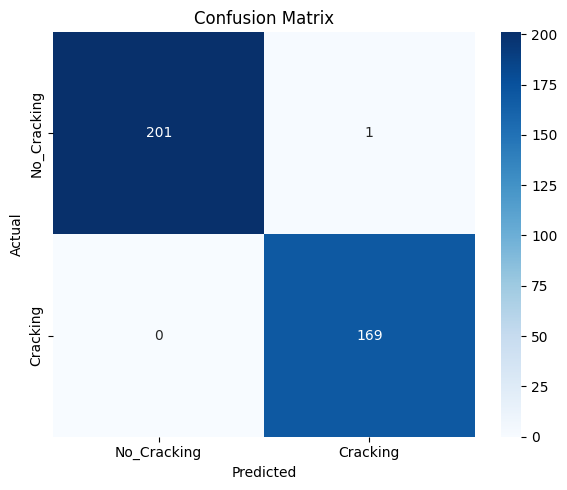

In [ ]:
cm = confusion_matrix(y_true, ft_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix ")
plt.tight_layout()
plt.show()

### Step 6 — Training History: Phase 1 vs Fine-Tuning

Plot both training runs side-by-side to see whether fine-tuning improved generalization.

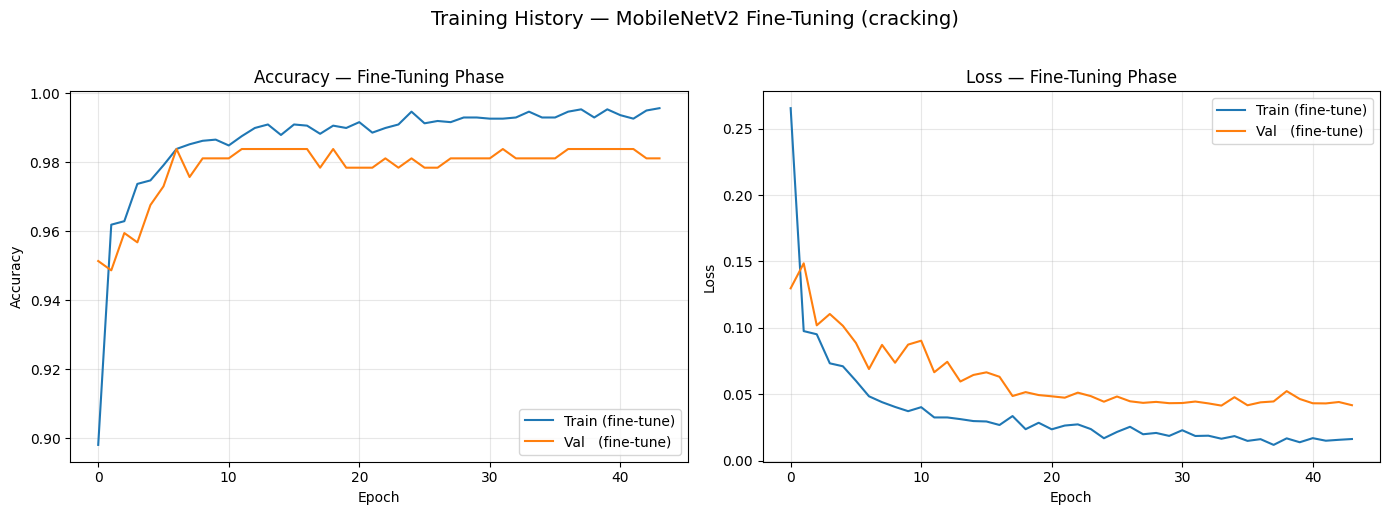

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(ft_history.history["accuracy"],     label="Train (fine-tune)")
axes[0].plot(ft_history.history["val_accuracy"],  label="Val   (fine-tune)")
axes[0].set_title("Accuracy — Fine-Tuning Phase")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(ft_history.history["loss"],     label="Train (fine-tune)")
axes[1].plot(ft_history.history["val_loss"],  label="Val   (fine-tune)")
axes[1].set_title("Loss — Fine-Tuning Phase")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History — MobileNetV2 Fine-Tuning (cracking)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step 7 — Save the Fine-Tuned Model

In [11]:
FT_FINAL_PATH = "mobilenetv2_cracking_finetuned_final.h5"
ft_best.save(FT_FINAL_PATH)
print(f"✅ Fine-tuned model saved → {FT_FINAL_PATH}")

✅ Fine-tuned model saved → mobilenetv2_cracking_finetuned_final.h5
